In [1]:
# INIT

import pandas as pd
import json
from pathlib import Path


district_nums = [(8,5), (10,4), (16,5), (20,4), (40,1), (80,1)]
election_methods = ["STV", "IRV", "Plurality"]
district_mode = ["cambridge", "slate_pl", "slate_bt"]
parties = ["D", "R"]
party_focal = parties[1]
party_nonfocal = parties[0]
party_focal_name = "Republican"
races = ["H", "O"]
race_focal = races[0]
plans = ["000", "200", "400", "600", "800"]
num_profiles_per_district = 100

Download complete.
Font file size (bytes): 141600


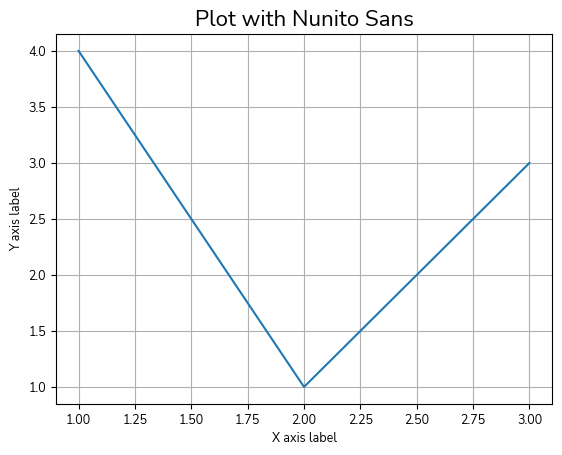

In [9]:
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os


url = "https://raw.githubusercontent.com/googlefonts/NunitoSans/main/fonts/ttf/NunitoSans-Regular.ttf"
font_path = "NunitoSans-Regular.ttf"
font_family = 'Nunito Sans' # Matplotlib needs the exact font name

try:
    print(f"Downloading font from: {url}")
    urllib.request.urlretrieve(url, font_path)
    print("Download complete.")

    file_size = os.path.getsize(font_path)
    print("Font file size (bytes):", file_size)
    
    # Register in Matplotlib
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_family

    # Quick test plot
    plt.figure()
    plt.title(f"Plot with {font_family}", fontsize=16)
    plt.xlabel("X axis label")
    plt.ylabel("Y axis label")
    plt.plot([1, 2, 3], [4, 1, 3])
    plt.grid(True)
    plt.show()
    
except Exception as e:
    print(f"An error occurred: {e}")
    print("Check the URL again or ensure Matplotlib is correctly installed with FreeType support.")


## Histograms of Hispanic seat count for each district x seat configuration

In [2]:
from process_util import count_focal_winners

rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    if eln > 1:
        election_methods = ["STV"]
    else:
        election_methods = ["IRV", "Plurality"]

    for dm in district_mode:
        for election_method in election_methods:
            results_file=Path(f"./vk_ca_election_model_results_racial/{dm}/ca_{dn}_districts_{eln}_{election_method}_racial_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

            with open(results_file, "r") as f:
                data = json.load(f)
                plan_data_len = len(data) // len(plans)

                # First split each result file into results from eachp plan
                results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

                # For each grouped results by plan
                for pn in range(len(results_by_plan)):
                    res_plan = results_by_plan[pn]

                    # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                    results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                    # For each district
                    for dist_id in range(len(results_by_district)):
                        res_dist = results_by_district[dist_id]

                        # For each rep
                        for rep_n in range(len(res_dist)):
                            # Result per rep
                            rep_res = res_dist[rep_n]
                            # Calculate average proportion across vk election results
                            rep_count = count_focal_winners(rep_res, race_focal)
                            
                            # Add census demographic info from settings file
                            settings_folder = Path(f"./vk_run_settings_racial/{dn}")
                            settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                            settings_filepath = settings_folder / settings_filename

                            with open(settings_filepath, "r") as g:
                                settings_data = json.load(g)
                                total_hvap = settings_data.get("total_hvap", None)
                                total_vap = settings_data.get("total_vap", None)                        
                                rows.append({"plan": plans[pn],
                                            "total_district_num": dn,
                                            "seats_per_district": eln,
                                            "election_method": election_method,
                                            "dist_num": dist_id,
                                            "mode": dm,
                                            "vap": total_vap,
                                            "hvap": total_hvap,
                                            "rep": rep_n,
                                            "H_seats": rep_count})

df_hist = pd.DataFrame(rows)
# df_hist.head()

## Histogram where each mode is divided

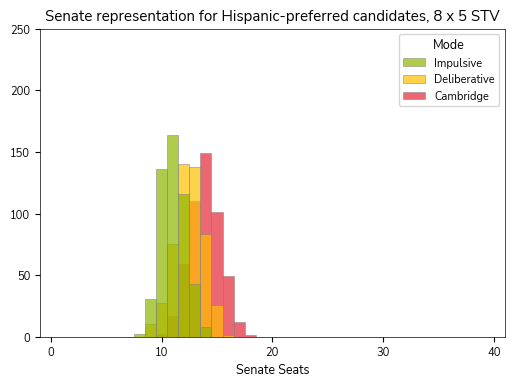

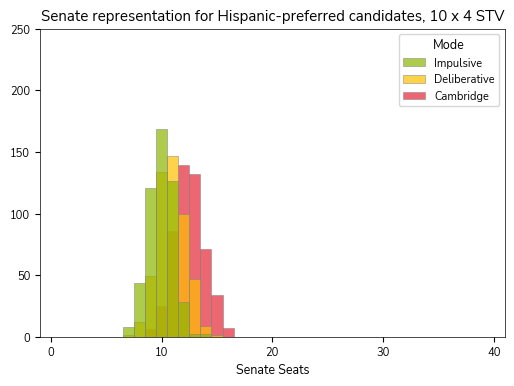

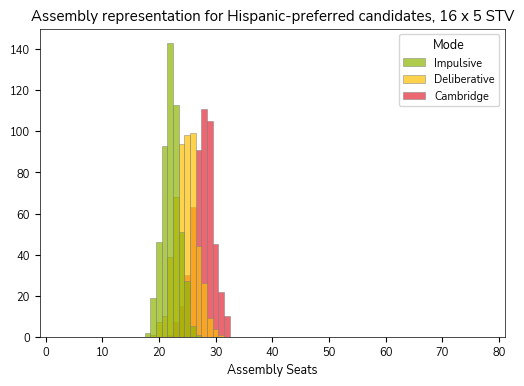

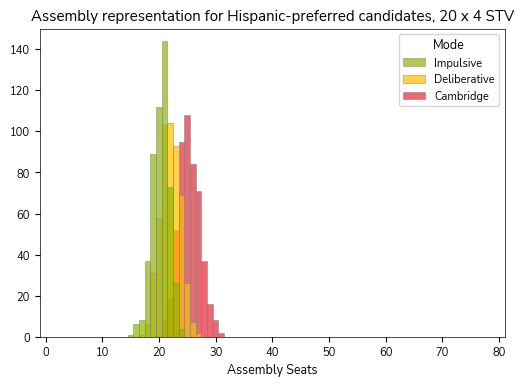

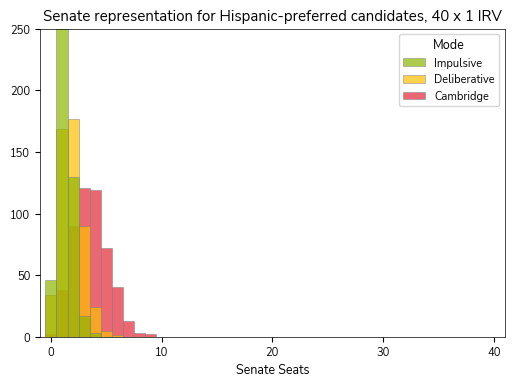

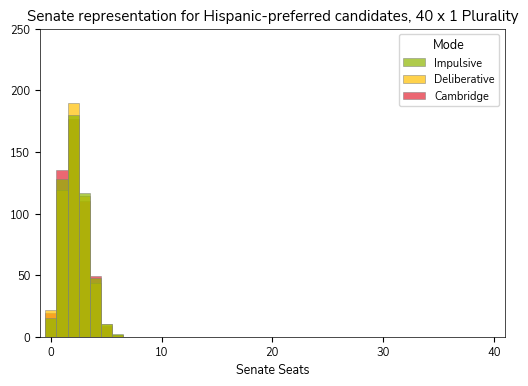

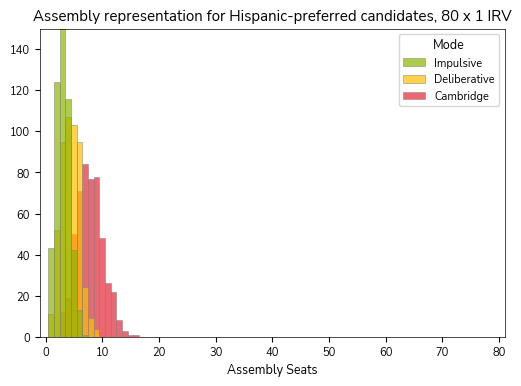

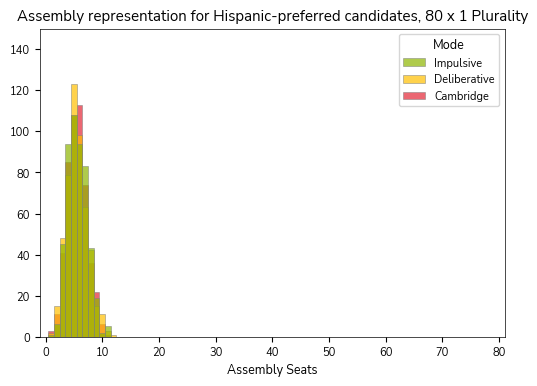

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans', "Arial"]

agg = (df_hist.groupby(["plan", "total_district_num", "mode", "rep", "election_method"], as_index=False)
      .agg({"H_seats": "sum"}))

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}


# Define colors for each mode
mode_colors = {
    "cambridge": "#E32636",
    "slate_bt": "#FFBF00",
    "slate_pl": "#8DB600"
}
# Define the mapping for the new legend labels
legend_mapping = {
    "slate_bt": "Deliberative",
    "slate_pl": "Impulsive",
    "cambridge": "Cambridge"}

# Define the desired order for the legend keys
desired_order = ["slate_pl", "slate_bt", "cambridge"]

for (dn,election_method), group_dn in agg.groupby(["total_district_num", "election_method"]): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes

    # Plot histogram for each mode
    for mode, group_mode in group_dn.groupby("mode"):
        alpha_val = 0.7 if mode_colors.get(mode) == "#8DB600" else 0.7
        ax.hist(
            group_mode["H_seats"],
            bins=range(group_mode["H_seats"].min(), group_mode["H_seats"].max() + 2),
            align='left',
            edgecolor='gray',
            linewidth=0.5,
            color=mode_colors.get(mode, "xkcd:light gray"),
            alpha=alpha_val,
            label=mode  # add label for legend
        )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = election_method
    ylim = 250 if sen_assem == "Senate" else 150

    # set x-axis limits on the Axes
    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")

    ax.set_title(f"{sen_assem} representation for Hispanic-preferred candidates, {dn} x {dist_seats[dn]} {election}")
    ax.tick_params(axis='both', which='major', labelsize=8)

    
    # ADD A MODIFIED LEGEND
    
    # 1. Get all handles and labels (including vertical lines if present)
    handles, labels = ax.get_legend_handles_labels()
    
    # 2. Map original labels to their handles and new descriptive labels
    # We only care about the histogram labels (the keys in legend_mapping)
    handle_map = {label: handle for handle, label in zip(handles, labels) if label in legend_mapping}

    # 3. Rebuild lists in the desired order
    ordered_handles = []
    ordered_labels = []
    
    for mode_key in desired_order:
        # Check if the handle for this mode exists (it should, but safety first)
        if mode_key in handle_map:
            ordered_handles.append(handle_map[mode_key])
            ordered_labels.append(legend_mapping[mode_key]) # Use the descriptive label

    # 4. Add legend for modes using the new labels and order
    ax.legend(ordered_handles, ordered_labels, title="Mode", fontsize=8)



    # ### ADD VERTICAL LINES
    # color_cs = 'xkcd:brownish grey'
    # color_hprop = 'xkcd:purplish brown'

    # ## Add vertical line for combined support
    # h_cs_share = h_cs_turnout*dn*dist_seats[dn]
    # ax.axvline(
    #     h_cs_share, color=color_cs, linewidth=1,
    #     label=f"{h_share}"
    # )

    # rounded_cs = f"{h_cs_share:.2f}"
    # cs_text_label = f"Combined support\n{h_cs_turnout*100:.2f}%\n({h_cs_share:.2f} seats)"
    # ax.text(
    #     h_cs_share - 0.5, # X-position: slightly to the right of the line
    #     ylim * 0.90, # Y-position: 95% of the way up the plot
    #     cs_text_label,
    #     verticalalignment='center',
    #     horizontalalignment='right',
    #     fontsize=8,
    #     color=color_cs
    # )
    
    # ## Add vertical line for population proprotionate share
    # # Add dotted vertical line at hprop * seats
    # h_share = hprop*dn*dist_seats[dn]
    # ax.axvline(
    #     h_share, color=color_hprop, linestyle=':', linewidth=1,
    #     label=f"{h_share}"
    # )
    
    # text_label = f"HVAP\n{hprop*100:.2f}%\n({h_share:.2f} seats)"

    # ax.text(
    #     h_share + 0.5, # X-position: slightly to the right of the line
    #     ylim * 0.90, # Y-position: 95% of the way up the plot
    #     text_label,
    #     verticalalignment='center',
    #     horizontalalignment='left',
    #     fontsize=8,
    #     color=color_hprop
    # )

    # # Save figure
    plt.savefig(f"figures/hispanic_seats_{dn}x{dist_seats[dn]}_{election_method}.png", dpi=300, bbox_inches='tight')

## Histograms of Partisan seat count for each config

In [6]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:
    # For each mode
    if eln > 1:
        election_methods = ["STV"]
    else:
        election_methods = ["IRV", "Plurality"]

    for dm in district_mode:
        for election_method in election_methods:
            results_file=Path(f"./vk_ca_election_model_results_partisan/{dm}/ca_{dn}_districts_{eln}_{election_method}_partisan_winners_for_voter_model_{dm}.json")


            # For each results file, first divide into results from dn different plans
            # Within each plan, each district was repeated by num_profiles_per_district=100
            # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

            with open(results_file, "r") as f:
                data = json.load(f)
                plan_data_len = len(data) // len(plans)

                # First split each result file into results from eachp plan
                results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

                # For each grouped results by plan
                for pn in range(len(results_by_plan)):
                    res_plan = results_by_plan[pn]

                    # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                    results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                    # For each district
                    for dist_id in range(len(results_by_district)):
                        res_dist = results_by_district[dist_id]

                        # For each rep
                        for rep_n in range(len(res_dist)):
                            # Result per rep
                            rep_res = res_dist[rep_n]
                            # Calculate average proportion across vk election results
                            rep_count = count_focal_winners(rep_res, party_focal)
                            
                            # Add census demographic info from settings file
                            settings_folder = Path(f"./vk_run_settings_partisan/{dn}")
                            settings_filename = f"ca_{dn}_vk_sample_settings_partisan_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                            settings_filepath = settings_folder / settings_filename

                            with open(settings_filepath, "r") as g:
                                settings_data = json.load(g)
                                bloc_pr = settings_data.get("bloc_proportions", None)      
                                bloc_vap = settings_data.get("vap", None)                   
                                rows.append({"plan": plans[pn],
                                            "total_district_num": dn,
                                            "seats_per_district": eln,
                                            "dist_num": dist_id,
                                            "mode": dm,
                                            "p_prop_census": bloc_pr[party_focal]/(bloc_pr[party_focal]+bloc_pr[party_nonfocal]),
                                            "vap": bloc_vap,
                                            "rep": rep_n,
                                            "party_seats": rep_count,
                                            "election_method": election_method})





df_part = pd.DataFrame(rows)
df_part.head()

,plan,total_district_num,seats_per_district,dist_num,mode,p_prop_census,vap,rep,party_seats,election_method
0,000,8,5,0,cambridge,0.254015,None,0,2,STV
1,000,8,5,0,cambridge,0.254015,None,1,1,STV
2,000,8,5,0,cambridge,0.254015,None,2,1,STV
3,000,8,5,0,cambridge,0.254015,None,3,2,STV
4,000,8,5,0,cambridge,0.254015,None,4,1,STV


In [ ]:
## Get party proportions

import pandas as pd
from IPython.display import display, HTML
import numpy as np

df_filtered = df_part[
    (df_part["plan"] == "000") &
    (df_part["mode"] == "cambridge") &
    (df_part["rep"] == 0) &
    (df_part["total_district_num"] == 8)
]

display(HTML(f"<div style='height:400px; overflow:auto'>{df_filtered.to_html()}</div>"))

print(sum(df_filtered["vap"]))
vap = sum(df_filtered["vap"])
pprop = np.dot(df_filtered["p_prop_census"], df_filtered["vap"])/vap

print(pprop)

## Compute combined support
p_cs = pprop * 0.85 + (1-pprop) * 0.15
#cs_turnout = hprop_turnout * 0.75 + (1-hprop_turnout) * 0.2
print(p_cs)


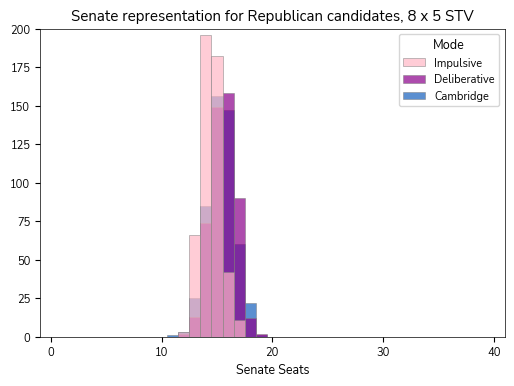

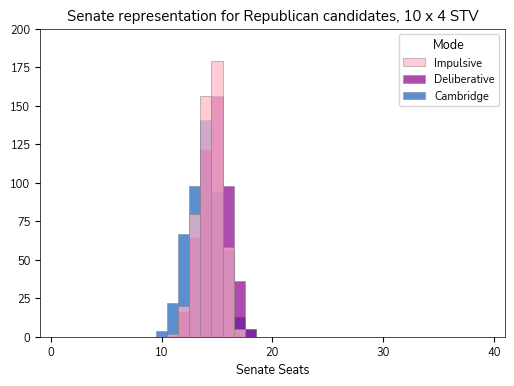

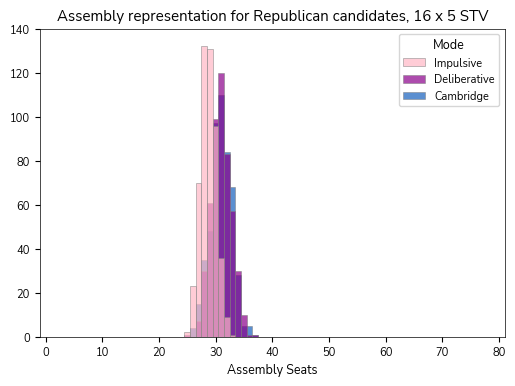

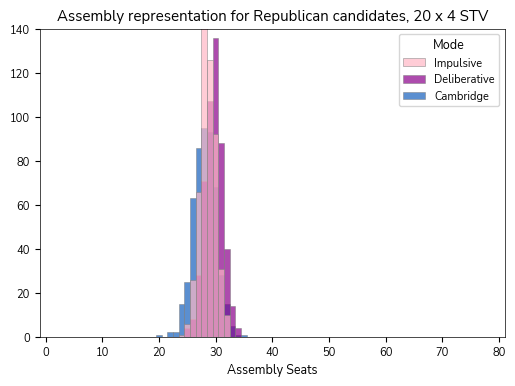

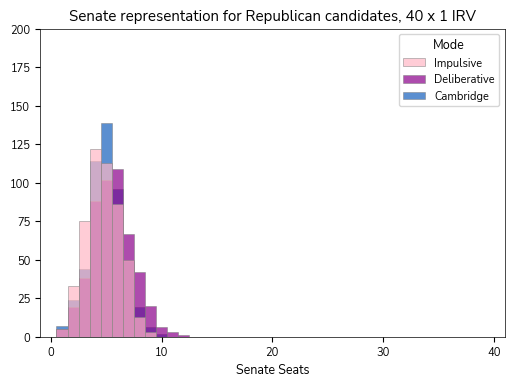

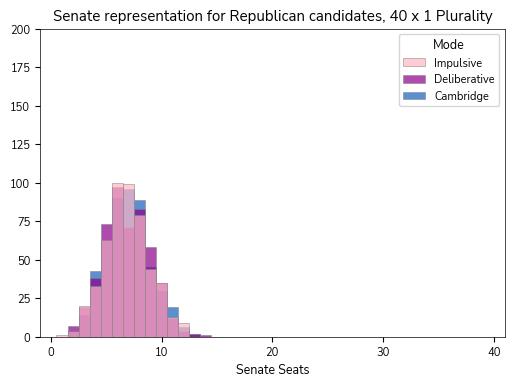

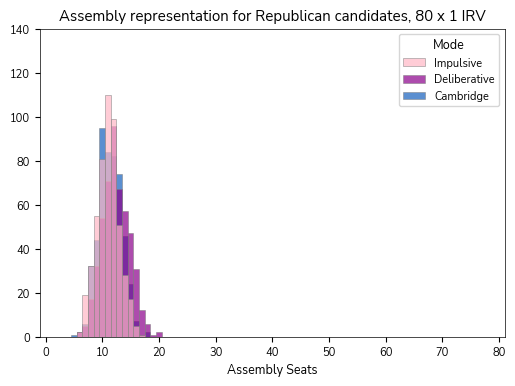

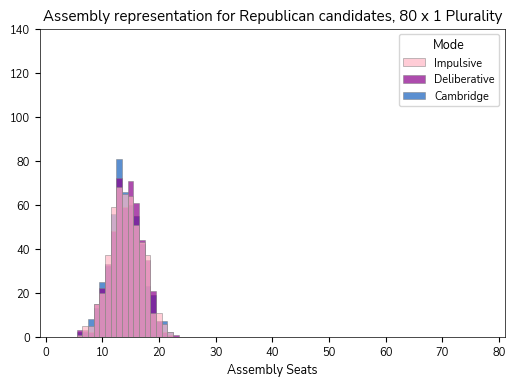

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans', "Arial"]

agg = (df_part.groupby(["plan", "total_district_num", "mode", "rep", "election_method"], as_index=False)
      .agg({"party_seats": "sum"}))

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# Define colors for each mode
mode_colors = {
    "cambridge": "#1560BD",
    "slate_bt": "#8B008B",
    "slate_pl": "#FFB7C5"
}
# Define the mapping for the new legend labels
legend_mapping = {
    "slate_bt": "Deliberative",
    "slate_pl": "Impulsive",
    "cambridge": "Cambridge"}

# Define the desired order for the legend keys
desired_order = ["slate_pl", "slate_bt", "cambridge"]

for (dn, election_method), group_dn in agg.groupby(["total_district_num", "election_method"]): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes

    # Plot histogram for each mode
    for mode, group_mode in group_dn.groupby("mode"):
        alpha_val = 0.7 if mode_colors.get(mode) == "#8DB600" else 0.7
        ax.hist(
            group_mode["party_seats"],
            bins=range(group_mode["party_seats"].min(), group_mode["party_seats"].max() + 2),
            align='left',
            edgecolor='gray',
            linewidth=0.5,
            color=mode_colors.get(mode, "xkcd:light gray"),
            alpha=alpha_val,
            label=mode  # add label for legend
        )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = election_method
    ylim = 200 if sen_assem == "Senate" else 140

    # set x-axis limits on the Axes
    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")

    ax.set_title(f"{sen_assem} representation for {party_focal_name} candidates, {dn} x {dist_seats[dn]} {election}")
    ax.tick_params(axis='both', which='major', labelsize=8)


    # ADD A MODIFIED LEGEND
    
    # 1. Get all handles and labels (including vertical lines if present)
    handles, labels = ax.get_legend_handles_labels()
    
    # 2. Map original labels to their handles and new descriptive labels
    # We only care about the histogram labels (the keys in legend_mapping)
    handle_map = {label: handle for handle, label in zip(handles, labels) if label in legend_mapping}

    # 3. Rebuild lists in the desired order
    ordered_handles = []
    ordered_labels = []
    
    for mode_key in desired_order:
        # Check if the handle for this mode exists (it should, but safety first)
        if mode_key in handle_map:
            ordered_handles.append(handle_map[mode_key])
            ordered_labels.append(legend_mapping[mode_key]) # Use the descriptive label

    # 4. Add legend for modes using the new labels and order
    ax.legend(ordered_handles, ordered_labels, title="Mode", fontsize=8)


    # ### ADD VERTICAL LINES
    # color_cs = 'xkcd:purplish grey'
    # color_pprop = 'xkcd:twilight'

    # ## Add vertical line for combined support
    # p_cs_share = p_cs*dn*dist_seats[dn]
    # ax.axvline(
    #     p_cs_share, color=color_cs, linewidth=1,
    #     label=f"{p_cs_share}"
    # )

    # rounded_cs = f"{p_cs_share:.2f}"
    # cs_text_label = f"Combined support\n{p_cs*100:.2f}%\n({rounded_cs} seats)"
    # ax.text(
    #     p_cs_share + 0.5, # X-position: slightly to the right of the line
    #     ylim * 0.90, # Y-position: 95% of the way up the plot
    #     cs_text_label,
    #     verticalalignment='center',
    #     horizontalalignment='left',
    #     fontsize=8,
    #     color=color_cs
    # )
    
    # ## Add vertical line for population proprotionate share
    # # Add dotted vertical line at hprop * seats
    # p_share = pprop*dn*dist_seats[dn]
    # ax.axvline(
    #     p_share, color=color_pprop, linestyle=':', linewidth=1,
    #     label=f"{p_share}"
    # )
    
    # rounded_share = f"{p_share:.2f}"
    # text_label = f"{party_focal_name} share\n{pprop*100:.2f}%\n({rounded_share} seats)"

    # ax.text(
    #     p_share - 0.5, # X-position: slightly to the right of the line
    #     ylim * 0.90, # Y-position: 95% of the way up the plot
    #     text_label,
    #     verticalalignment='center',
    #     horizontalalignment='right',
    #     fontsize=8,
    #     color=color_pprop
    # )

    # # Save figure
    plt.savefig(f"figures/{party_focal_name}_seats_{dn}x{dist_seats[dn]}_{election_method}.png", dpi=300, bbox_inches='tight')